In [1]:
#Class dataset for MRI 
import os
import pickle
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset
import cv2  # used for resizing
class MRISliceDataset(Dataset):
    def __init__(self, root_dir, metadata_csv, transform=None, max_files=50, target_size=(320, 320)):
        self.root_dir = root_dir
        self.metadata = pd.read_csv(metadata_csv)
        self.transform = transform
        self.target_size = target_size
        # Keep only first N volumes
        unique_volumes = self.metadata["volumeFilename"].unique()[:max_files]
        self.metadata = self.metadata[self.metadata["volumeFilename"].isin(unique_volumes)]
        self.samples = []
        for _, row in self.metadata.iterrows():
            vol_path = os.path.join(root_dir, row["volumeFilename"])
            if not os.path.exists(vol_path):
                continue
            try:
                with open(vol_path, "rb") as f:
                    volume = pickle.load(f)
                num_slices = volume.shape[0]
            except Exception as e:
                print(f"⚠️ Skipping {vol_path}: {e}")
                continue

            roi_start = int(row["roiZ"])
            roi_end = roi_start + int(row["roiDepth"]) - 1

            for i in range(num_slices):
                label = 1 if roi_start <= i <= roi_end else 0
                self.samples.append((vol_path, i, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        vol_path, slice_idx, label = self.samples[idx]

        with open(vol_path, "rb") as f:
            volume = pickle.load(f)

        image = volume[slice_idx].astype(np.float32)
        image = image / np.max(image) if np.max(image) > 0 else image

        # ✅ Resize to target_size using OpenCV (H, W)
        image = cv2.resize(image, self.target_size, interpolation=cv2.INTER_LINEAR)

        # Add channel dimension
        image = np.expand_dims(image, axis=0)
        image = torch.tensor(image, dtype=torch.float32)
        label = torch.tensor(label, dtype=torch.long)

        if self.transform:
            image = self.transform(image)

        return image, label


In [1]:
#LeNet Model 
import torch
import torch.nn as nn
import torch.nn.functional as F
#     para = {
#         'input_image_size': (320, 320),
#         'input_channel': 1,
#         'number_of_conv_layer':2,
#         'number_of_fc_layer':2,
#         'num_classes':2,
#     }

class LeNet(nn.Module):
    def __init__(self, para):
        super(LeNet,self).__init__()
        self.para=para
        self.input_image_size=para['input_image_size']
        self.input_channel=para['input_channel']
        self.num_conv_layer=para['number_of_conv_layer']
        self.num_fc_layer=para['number_of_fc_layer']
        self.fc_feateure=para['fc_feature']
        self.conv_channels=para['conv_channels']
        self.Conv_layer=nn.ModuleList()
        self.FC_layer=nn.ModuleList()
        self.build_conv_layer()
        self.build_fc_layer()
    def build_conv_layer(self):
        for i in range(self.num_conv_layer):
            in_channels=self.input_channel if i==0 else self.conv_channels[i-1]
            out_channels=self.conv_channels[i]
            conv=nn.Sequential(nn.Conv2d(in_channels,out_channels,kernel_size=7,stride=1,padding=2),
                               nn.BatchNorm2d(out_channels),
                               nn.ReLU(),
                                nn.MaxPool2d(kernel_size=2,stride=2))
            self.Conv_layer.append(conv)
    def forward_convs(self, x):
        for conv in self.Conv_layer:
            x = conv(x)
        return x

    def build_fc_layer(self):
        in_features=0
        with torch.no_grad():
            x=torch.randn(1,self.input_channel,self.input_image_size[0],self.input_image_size[1])
            x=self.forward_convs(x)
            in_features=x.flatten(1).shape[1]
        fc=nn.Sequential(nn.Linear(in_features,self.fc_feateure[0]),
                         nn.ReLU(),
                         nn.Linear(self.fc_feateure[0],self.fc_feateure[1]),
                         nn.Softmax(dim=1))
        self.FC_layer.append(fc)
    def forward_fc(self, x):
        x = x.flatten(1)
        for fc in self.FC_layer:
            x = fc(x)
        return x

    def forward(self, x):
        x = self.forward_convs(x)
        x = self.forward_fc(x)
        return x
    def summary(self):
        print("="*40)
        print(f"{'Layer':<15}{'Output Shape':<20}{'Details'}")
        print("="*40)
        for i, conv in enumerate(self.Conv_layer):
            print(f"Conv{i+1:<10} {str(conv):<20}")
        for i, fc in enumerate(self.FC_layer):
            print(f"FC{i+1:<10} {str(fc):<20}")
        print("="*40)

if __name__ == "__main__":
    para = {
        'input_image_size': (320, 320),
        'input_channel': 1,
        'number_of_conv_layer':2,
        'number_of_fc_layer':2,
        'num_classes':2,
        'conv_channels': [6, 16],
        'fc_feature':[84,2]
    }

    model = LeNet(para)
    x = torch.randn(1, 1, 320, 320)
    y = model(x)
    print("Output shape:", y.shape)
    print(f"Predicted class:{y}")
    model.summary()

Output shape: torch.Size([1, 2])
Predicted class:tensor([[0.5217, 0.4783]], grad_fn=<SoftmaxBackward0>)
Layer          Output Shape        Details
Conv1          Sequential(
  (0): Conv2d(1, 6, kernel_size=(7, 7), stride=(1, 1), padding=(2, 2))
  (1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)
Conv2          Sequential(
  (0): Conv2d(6, 16, kernel_size=(7, 7), stride=(1, 1), padding=(2, 2))
  (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)
FC1          Sequential(
  (0): Linear(in_features=97344, out_features=84, bias=True)
  (1): ReLU()
  (2): Linear(in_features=84, out_features=2, bias=True)
  (3): Softmax(dim=1)
)


In [4]:
class EarlyStopping:
    def __init__(self, patience=5, delta=0):
        self.patience = patience
        self.delta = delta
        self.best_score = None
        self.early_stop = False
        self.counter = 0
        self.best_model_state = None

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.best_model_state = model.state_dict()
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.best_model_state = model.state_dict()
            self.counter = 0

    def load_best_model(self, model):
        model.load_state_dict(self.best_model_state)

In [5]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm
class Trainer:
    def __init__(self, model, train_dataset, val_dataset,
                 batch_size=64, lr=1e-4, device=None):
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.model = model.to(self.device)
        print(f"Train set size: {len(train_dataset)}")
        print(f"Val set size: {len(val_dataset)}")
        #Sampler 
        self.sample_count=torch.bincount(torch.tensor([label for _, label in train_dataset]))
        self.weights=1.0/self.sample_count.float()
        self.sample_weights=self.weights[[label for _, label in train_dataset]]
        self.sampler=torch.utils.data.WeightedRandomSampler(self.sample_weights,num_samples=len(self.sample_weights),replacement=True)
        # Dataloaders
        self.train_loader = DataLoader(train_dataset, batch_size=batch_size,sampler=self.sampler)
        self.val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True) 
        # Loss and optimizer
        self.criterion = nn.CrossEntropyLoss()  # binary classification
        self.optimizer = torch.optim.SGD(self.model.parameters(),lr=lr)
    def train_epoch(self):
        self.model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        loop = tqdm(self.train_loader, desc="Training", leave=False)
        for images, labels in loop:
            images, labels = images.to(self.device), labels.to(self.device)
            # Forward
            outputs = self.model(images).squeeze(1)  # [B] or [B,1]
            loss = self.criterion(outputs, labels)
            # Backward
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            # Metrics
            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels.long()).sum().item()
            total += labels.size(0)
            loop.set_postfix(loss=loss.item())

        avg_loss = running_loss / total
        acc = correct / total
        return avg_loss, acc

    def validate_epoch(self):
        if self.val_loader is None:
            return None, None

        self.model.eval()
        running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            loop = tqdm(self.val_loader, desc="Validating", leave=False)
            for images, labels in loop:
                images, labels = images.to(self.device), labels.to(self.device)
                outputs = self.model(images).squeeze(1)
                loss = self.criterion(outputs, labels)
                running_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                correct += (preds == labels.long()).sum().item()
                total += labels.size(0)

        avg_loss = running_loss / total
        acc = correct / total
        return avg_loss, acc

    def fit(self, epochs=2):
        print(f"Training on device: {self.device}")
        for epoch in range(1, epochs + 1):
            train_loss, train_acc = self.train_epoch()
            val_loss, val_acc = self.validate_epoch() if self.val_loader else (None, None)
            msg = f"Epoch [{epoch}/{epochs}] | Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}"
            if val_loss is not None:
                msg += f" | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
            print(msg)


In [6]:
from torch.utils.data import random_split
from collections import Counter
full_dataset = MRISliceDataset("./MRI_dataset/volumetric_data/", "./MRI_dataset/metadata.csv",max_files=300)
train_size = int(0.7 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_ds, val_ds = random_split(full_dataset, [train_size, val_size])
print(f"Len of train set:{len(train_ds)}")
print(f"Len of val set:{len(val_ds)}")
labels_train=[train_image[1].item() for train_image in train_ds]
print(f"="*10)
count_train=Counter(labels_train)
print(count_train)
labels_val=[val_img[1].item() for val_img in val_ds]
count_val=Counter(labels_val)
print("="*10)
print(count_val)
para = {
        'input_image_size': (320, 320),
        'input_channel': 1,
        'number_of_conv_layer':2,
        'number_of_fc_layer':2,
        'num_classes':2,
        'conv_channels': [6, 16],
        'fc_feature':[84,2]
    }
    
model = LeNet(para)
trainer = Trainer(model, train_ds, val_ds, batch_size=128, lr=1e-3)



Len of train set:6353
Len of val set:2724
Counter({0: 5661, 1: 692})
Counter({0: 2418, 1: 306})
Train set size: 6353
Val set size: 2724


In [ ]:
trainer.fit(epochs=20)
torch.save(model.state_dict(),'model.pth')
print("Saved PyTorch Model State to model.pth")

In [7]:
test_set=MRISliceDataset('./MRI_dataset/volumetric_data','./MRI_dataset/metadata.csv',max_files=900)
test_ds=torch.utils.data.Subset(test_set,range(300,900))
test_loader=DataLoader(test_ds,batch_size=256,shuffle=True)
model.load_state_dict(torch.load('model.pth',weights_only=False))
device="cuda" if torch.cuda.is_available() else "cpu"
model.to(device)


LeNet(
  (Conv_layer): ModuleList(
    (0): Sequential(
      (0): Conv2d(1, 6, kernel_size=(7, 7), stride=(1, 1), padding=(2, 2))
      (1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(6, 16, kernel_size=(7, 7), stride=(1, 1), padding=(2, 2))
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (FC_layer): ModuleList(
    (0): Sequential(
      (0): Linear(in_features=97344, out_features=84, bias=True)
      (1): ReLU()
      (2): Linear(in_features=84, out_features=2, bias=True)
      (3): Softmax(dim=1)
    )
  )
)

Test Accuracy: 95.0000%
Recall (Sensitivity): 100.00000000%
Saved test results to test_results.csv


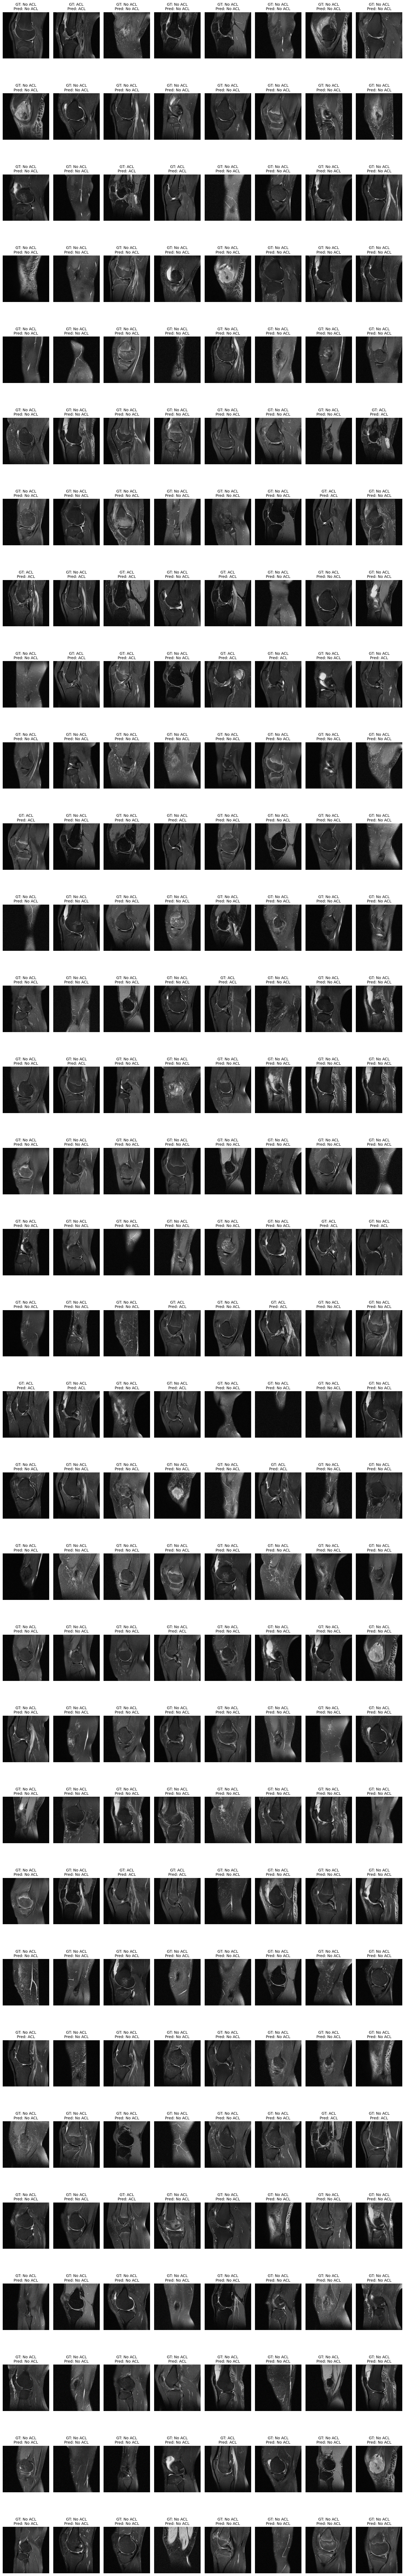

In [9]:
import torch
import pandas as pd
from sklearn.metrics import recall_score
import matplotlib.pyplot as plt

results = []
correct = 0
total = 0
y_true = []
y_pred = []
model.eval()

# Collect a few images for visualization
images_to_show = []
labels_to_show = []
preds_to_show = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Save for metrics
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

        # Save for CSV
        for lbl, pred in zip(labels.cpu(), predicted.cpu()):
            results.append({'True Label': lbl.item(), 'Predicted': pred.item()})
        
        # Save a few samples to visualize (max 20 images)
        if len(images_to_show) < 30:
            images_to_show.extend(images.cpu())
            labels_to_show.extend(labels.cpu())
            preds_to_show.extend(predicted.cpu())

# === Compute recall ===
recall = recall_score(y_true, y_pred, pos_label=1)  # assumes 1 = ACL present

print(f"Test Accuracy: {100 * correct / total:.4f}%")
print(f"Recall (Sensitivity): {recall * 100:.8f}%")

# === Save results to CSV ===
df = pd.DataFrame(results)
df.to_csv("test_results.csv", index=False)
print("Saved test results to test_results.csv")

# === Display some sample predictions ===
n_show = len(images_to_show)
cols = 8
rows = (n_show + cols - 1) // cols

plt.figure(figsize=(15, rows * 3))
for idx in range(n_show):
    img = images_to_show[idx]
    true_label = labels_to_show[idx].item()
    pred_label = preds_to_show[idx].item()

    # if grayscale (1, H, W) → (H, W)
    if img.ndim == 3 and img.shape[0] == 1:
        img = img.squeeze(0)

    plt.subplot(rows, cols, idx + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"GT: {'ACL' if true_label==1 else 'No ACL'}\nPred: {'ACL' if pred_label==1 else 'No ACL'}",
              fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()
